In [1]:
%load_ext autoreload
%autoreload

In [10]:
import time
import numpy as np
import sys
import os
from tqdm.auto import tqdm
import brainpy as bp
import brainpy.math as bm
import traceback
from glob import glob
import zipfile
from pathlib import Path
import matplotlib.pyplot as plt
import importlib


In [11]:
def get_parent_dir():
    try:

        return Path(__file__).resolve().parent.parent
    except NameError:

        return Path.cwd().parent

parent_dir = str(get_parent_dir())
print("Parent directory:", parent_dir)
sys.path.append(parent_dir)


Parent directory: C:\Users\HP\PycharmProjects\Internproject 2025\cerebellum-jax-main


In [17]:
# Figure 2DEF


def figure_2DEF(seed, mon, pfpc_idx):
    threshold = 2
    xrange = [30_000, 50_000]
    ts_idx = [max(np.where(mon.ts <= xrange[0])[0]), min(np.where(mon.ts >= xrange[1])[0])]
    sl = slice(ts_idx[0], ts_idx[1] + 1)
    PC_cspks_thr = (np.where(mon["pc.cspk"][ts_idx[0]:ts_idx[1]].sum(axis=0) >= threshold)[0]) # Find PC cells with lots of cspks
    if not len(PC_cspks_thr[1:3]):
        print('no cs')
    for PC in PC_cspks_thr[1:3]:
        cons_thr_idx = np.where(np.isin(pfpc_idx['post/pc'], PC))[0] # Find which conn indexes these PC cells are part of
        cons_thr_idx=  np.random.choice(cons_thr_idx, size=3, replace=False)  # Only select 3 connections to plot

        for connection in cons_thr_idx:

            norm = mon["pfpc_weights"][0, connection]

            xlim = [30_000, 50_000]
            ts_idx = [max(np.where(mon.ts <= xlim[0])[0]), min(np.where(mon.ts >= xlim[1])[0])]

            fig = plt.figure(figsize=(8, 12))
            gs = fig.add_gridspec(6, 2, height_ratios=[1, 1, 1, 1, 1, 1])

            fig.suptitle(experiment_name+ f"_seed_{seed}_PCnum_{PC}_con_num{connection}")

            # Total weight
            ax_w = fig.add_subplot(gs[0, :])
            ax_w.plot(mon.ts[sl], (mon["pfpc_weights"][sl, connection] - norm ) / norm)
            ax_w.set_title(r"$w$")
            ax_w.set_xlim(xlim)


            # CSpk weights; delta and total
            ax10 = fig.add_subplot(gs[1, 0])
            ax11 = fig.add_subplot(gs[1, 1])

            ax10.plot(mon.ts[sl], (mon["pfpc_dw_cspk"][sl, connection] - norm) / norm)
            ax10.set_title(r"$\Delta_{w CSpk}$")
            ax10.set_xlim(xlim)


            ax11.plot(mon.ts[sl], (mon["pfpc_w_cspk"][sl, connection] - norm) / norm)
            ax11.set_title(r"$w_{CSpk}$")
            ax11.set_xlim(xlim)

            # BCM weights ; delta and total
            ax20 = fig.add_subplot(gs[2, 0])
            ax21 = fig.add_subplot(gs[2, 1])

            ax20.plot(mon.ts[sl], (mon["pfpc_dw_BCM"][sl, connection] - norm) / norm)
            ax20.set_title(r"$\Delta_{w BCM}$")
            ax20.set_xlim(xlim)

            ax21.plot(mon.ts[sl], (mon["pfpc_w_BCM"][sl, connection] - norm) / norm)
            ax21.set_title(r"$w_{BCM}$")
            ax21.set_xlim(xlim)

            # PF firing
            ax_pf = fig.add_subplot(gs[3, :])
            current_PF_index = pfpc_idx['pre/pf'][connection]
            ax_pf.plot(mon.ts[sl], mon["pf.rho"][sl, current_PF_index])
            ax_pf.set_title(r"$\rho_{\mathrm{PF}}$")
            ax_pf.set_xlim(xlim)

            # PC firing
            ax_pc = fig.add_subplot(gs[4, :])
            ax_pc.plot(mon.ts[sl], mon["pc.rho"][sl, PC])
            ax_pc.set_title(r"$\rho_{\mathrm{PC}}$")
            ax_pc.set_xlim(xlim)

            # Sliding threshold
            ax_thresh = fig.add_subplot(gs[5, :])
            ax_thresh.plot(mon.ts[sl], mon["pfpc_theta_M"][sl, PC])
            ax_thresh.set_title(r"$\theta_{\mathrm{M}}$")
            ax_thresh.set_xlim(xlim)


            plt.tight_layout()


            fig.savefig(os.path.join(results_subdir, f"condition_plasticity_seed_{seed}_PCnum_{PC}_con_num{connection}.png"))



In [12]:
experiment_name = 'A_cspk_higher_long'
conditions= ["plasticity"] # "static"
SEEDS = [99]
DURATION = 50_100.0
DT = 0.025
BASE_NET_PARAMS = {}

print("Running Plasticity Experiment")

print(f"SEEDS: {', '.join(f'{x}' for x in SEEDS)}")
print(f"Total runs: {len(SEEDS)*len(conditions)}")
print("-" * 80)

results_subdir = os.path.join(
    parent_dir, "results", f"SynPlast_test_{time.strftime('%m-%d_%H;%M;%S')}"
)
os.makedirs(results_subdir, exist_ok=True)
print("Saving results to:", results_subdir)

%reload_ext autoreload

start_time = time.time()
runners = {}
pfpc = {}
for condition in conditions:
    print(f"Running {condition} condition")
    if condition == "plasticity":
        import models.network_plasticity as net
    elif condition == "static":
        import models.network as net

    importlib.reload(net)
    # print(net.VERSION)
    for seed in SEEDS:
        current_net_params = BASE_NET_PARAMS.copy()
        try:
            runner, pfpc_idx, init_weights = net.run_simulation(
            duration=DURATION, dt=DT, net_params=current_net_params, seed=seed)
        except Exception as e:
                full_error = traceback.format_exc()
                tqdm.write(f"Error during simulation: {e}\n{full_error}")

        runners[(condition, seed)] = runner
        pfpc[(condition, seed)] = pfpc_idx

        data = {k: np.array(runner.mon[k]) for k in runner.mon}
        run_path = os.path.join(
        results_subdir, f"condition_{condition}_seed_{seed}_runner.npz")
        np.savez(run_path, **data)




end_time = time.time()
print(f"Total time taken: {end_time - start_time:.2f} seconds")



Running Plasticity Experiment
SEEDS: 99
Total runs: 1
--------------------------------------------------------------------------------
Saving results to: C:\Users\HP\PycharmProjects\Internproject 2025\cerebellum-jax-main\results\SynPlast_test_02-19_16;26;36
Running plasticity condition
Total time taken: 456.18 seconds


In [ ]:
seed = 99
mon= runners[('plasticity', seed)].mon
pfpc_idx= pfpc[('plasticity', seed)]
figure_2DEF(seed, mon, pfpc_idx)

In [14]:
# with numpy.load('foo.npz') as data:
#     a = data['a']
# bm.exp(-dt / self.tau_inhib)
# # self.w_cspk.value = self.w_cspk.value*exp() + dw_cspk_increase


In [ ]:
# Figure 2B
seed = 99
mon= runners[('plasticity', seed)].mon
pfpc_idx= pfpc[('plasticity', seed)]

xrange = [0, 6_000]
ts_idx = [max(np.where(mon.ts <= xrange[0])[0]), min(np.where(mon.ts >= xrange[1])[0])]
t_rel, pc_idx = np.where(mon["pc.cspk"][ts_idx[0]:ts_idx[1]])
cspks = np.column_stack((t_rel + ts_idx[0], pc_idx)) #  column[0] = timestamps , column[1] = PC cell
cspks_selection = cspks[np.random.choice(cspks.shape[0], size=5, replace=False),:] # only plot 5 CSpk instances


fig, ax = plt.subplots(5, figsize=(6, 14))

for i, (timestamp, PC) in enumerate(cspks_selection):

    t_cspk = mon.ts[timestamp]
    xlim = [t_cspk - 200.0, t_cspk + 500.0] # Center plot around CSpk
    win_idx = (mon.ts >= xlim[0]) & (mon.ts <= xlim[1])
    ts_win= mon.ts[win_idx]
    ts_rel = ts_win-t_cspk # make time of CSpk = 0

    theta_win = mon["pfpc_theta_M"][win_idx, PC]
    pc_rate_win = mon["pc.rho"][win_idx, PC]

    ax[i].axvline(0.0, color='r', linestyle='--', linewidth=1)
    ax[i].plot(ts_rel, theta_win, label=r"$\theta_M$", color='C0')
    ax[i].plot(ts_rel, pc_rate_win, label=r"$\rho_{PC}$", color='C1')

    ax[i].fill_between(
        ts_rel, theta_win, pc_rate_win,
        where=(pc_rate_win > theta_win),
        color='C1', alpha=0.3, interpolate=True, label='Potentiation'
    )
    ax[i].fill_between(
        ts_rel, theta_win, pc_rate_win,
        where=(theta_win > pc_rate_win),
        color='C0', alpha=0.3, interpolate=True, label='Depression'
    )

    ax[i].set_xlim([-200, 500])
    ax[i].set_title(f"PC {PC} – complex spike at t = {t_cspk }ms")
    ax[i].set_xlabel("Time relative to CSpk (ms)")
    ax[i].set_ylabel("Rate / Theta")

ax[0].legend(bbox_to_anchor=(1.3, 1.0))
plt.tight_layout()


In [5]:
# PF scaling
SEEDS = [99]
conditions= [ "plasticity"]
scalings = [0.25,0.5]
DURATION = 50_100.0
DT = 0.025 # in ms
BASE_NET_PARAMS = {}

print("Running PF_scaling experiment")

print(f"SEEDS: {', '.join(f'{x}' for x in SEEDS)}")
print(f"Total runs: {len(SEEDS)*len(scalings)*len(conditions)}")
print("-" * 80)

results_subdir = os.path.join(
    parent_dir, "results", f"PF_scaling_{time.strftime('%m-%d_%H;%M;%S')}"
)
os.makedirs(results_subdir, exist_ok=True)
print("Saving results to:", results_subdir)

start_time = time.time()
runners = {}
pfpc = {}
for condition in conditions:

    for scale in scalings:
        print(f"Running condition = {condition}, PF_factor= {scale} ")
        if condition == "plasticity":
            import models.network_plasticity as net
        elif condition == "static":
            import models.network as net
        importlib.reload(net)

        for seed in SEEDS:
            current_net_params = BASE_NET_PARAMS.copy()
            current_net_params["pf_scaling"] = scale
            try:
                runner, pfpc_idx = net.run_simulation(
                duration=DURATION, dt=DT, net_params=current_net_params, seed=seed)
            except Exception as e:
                    full_error = traceback.format_exc()
                    tqdm.write(f"Error during simulation: {e}\n{full_error}")

            runname= f"{condition}_scale_{scale}"
            runners[(runname, seed)] = runner

            data = {k: np.array(runner.mon[k]) for k in runner.mon}
            run_path = os.path.join(
            results_subdir, f"tau_value_{scale}_seed_{seed}_runner.npz")
            np.savez(run_path, **data)






end_time = time.time()
print(f"Total time taken: {end_time - start_time:.2f} seconds")


Running PF_scaling experiment
SEEDS: 99
Total runs: 2
--------------------------------------------------------------------------------
Saving results to: C:\Users\HP\PycharmProjects\Internproject 2025\cerebellum-jax-main\results\PF_scaling_02-19_11;34;37
Running condition = plasticity, PF_factor= 0.25 
Running condition = plasticity, PF_factor= 0.5 
Total time taken: 977.76 seconds


In [ ]:
for condition in conditions:
    for scale in scalings:
        for seed in SEEDS:
             runname= f"{condition}_scale_{scale}"
             mon = runners[(runname, seed)].mon
             experiment_name = "PF_scaling_"+runname
             figure_2DEF(seed, mon, pfpc_idx)

In [7]:
# PC Rate experiment: different tau values for EMA
SEEDS = [99]
conditions= ["static", "plasticity"]
TAU_VALUES = np.linspace(0.100, 0.300, 3) # in seconds
DURATION = 8_000.0
DT = 0.025 # in ms
BASE_NET_PARAMS = {}

print("Running PC_rate experiment")

print(f"SEEDS: {', '.join(f'{x}' for x in SEEDS)}")
print(f"Total runs: {len(SEEDS)*len(TAU_VALUES)*len(conditions)}")
print("-" * 80)

results_subdir = os.path.join(
    parent_dir, "results", f"PC_rate_test_{time.strftime('%m-%d_%H;%M;%S')}"
)
os.makedirs(results_subdir, exist_ok=True)
print("Saving results to:", results_subdir)

start_time = time.time()
runners = {}
pfpc = {}
for condition in conditions:

    for tau_value in TAU_VALUES:
        print(f"Running condition = {condition}, tau= {tau_value} seconds")
        if condition == "plasticity":
            import models.network_plasticity as net
        elif condition == "static":
            import models.network as net
        importlib.reload(net)

        for seed in SEEDS:
            current_net_params = BASE_NET_PARAMS.copy()
            current_net_params["PC_tau_rate"] = tau_value
            try:
                runner, pfpc_idx = net.run_simulation(
                duration=DURATION, dt=DT, net_params=current_net_params, seed=seed)
            except Exception as e:
                    full_error = traceback.format_exc()
                    tqdm.write(f"Error during simulation: {e}\n{full_error}")

            runname= f"{condition}_tau_{tau_value}"
            runners[(runname, seed)] = runner

            data = {k: np.array(runner.mon[k]) for k in runner.mon}
            run_path = os.path.join(
            results_subdir, f"tau_value_{tau_value}_seed_{seed}_runner.npz")
            np.savez(run_path, **data)




end_time = time.time()
print(f"Total time taken: {end_time - start_time:.2f} seconds")

Running PC_rate experiment
SEEDS: 99
Total runs: 6
--------------------------------------------------------------------------------
Saving results to: C:\Users\HP\PycharmProjects\Internproject 2025\cerebellum-jax-main\results\PC_rate_test_02-12_08;58;51
Running condition = static, tau= 0.1 seconds
Running condition = static, tau= 0.2 seconds
Running condition = static, tau= 0.3 seconds
Running condition = plasticity, tau= 0.1 seconds
Running condition = plasticity, tau= 0.2 seconds
Running condition = plasticity, tau= 0.3 seconds
Total time taken: 172.01 seconds


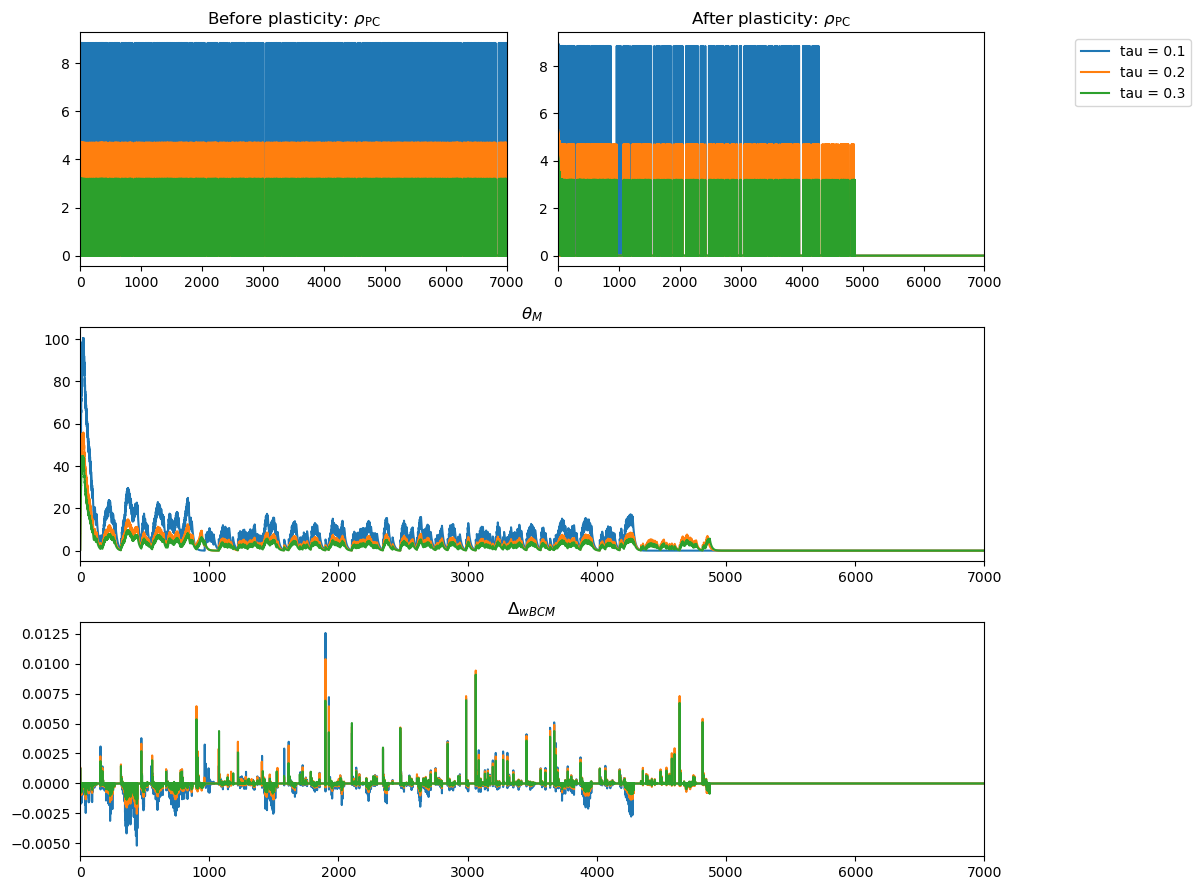

In [8]:
# Plot PC rate, BCM and sliding threshold
seed = 99
PC_cell= 23
xrange = [0, 7000]

fig = plt.figure(figsize=(12, 9))
gs = fig.add_gridspec(3, 2)

ax_pc   = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])]  # two columns
ax_th   = fig.add_subplot(gs[1, :])                               # span both columns
ax_bcm  = fig.add_subplot(gs[2, :])                               # span both columns

for i, condition in enumerate(conditions):
    for tau_value in TAU_VALUES:
        runname = f"{condition}_tau_{tau_value}"
        mon = runners[(runname, seed)].mon
        rho_PC = mon["pc.rho"]

        idx_conn = np.where(np.isin(pfpc_idx['post/pc'], PC_cell))[0][0]
        tau_value = np.round(tau_value, decimals=3)

        # PC Rate
        ax_pc[i].plot(mon.ts, rho_PC[:, PC_cell], label=f"tau = {tau_value}")

        if condition == "plasticity":
            theta_M = mon["pfpc_theta_M"]
            dw_BCM = mon["pfpc_dw_BCM"]

            ax_th.plot(mon.ts, theta_M[:, PC_cell], label=f"tau = {tau_value}")
            ax_bcm.plot(mon.ts, dw_BCM[:, idx_conn], label=f"tau = {tau_value}")

# PC Rate
ax_pc[0].set_title(r"Before plasticity: $\rho_{\mathrm{PC}}$")
ax_pc[1].set_title(r"After plasticity: $\rho_{\mathrm{PC}}$")
for a in ax_pc:
    a.set_xlim(xrange)
ax_pc[1].legend(bbox_to_anchor=(1.5, 1.0))

# Theta_M
ax_th.set_title(r"$\theta_M$ ")
ax_th.set_xlim(xrange)
# ax_th.legend(bbox_to_anchor=(1.3, 1.0))

# BCM weights
ax_bcm.set_title(r"$\Delta_{w BCM}$ ")
ax_bcm.set_xlim(xrange)
# ax_bcm.legend(bbox_to_anchor=(1.3, 1.0))

plt.tight_layout()
fig.savefig(os.path.join(results_subdir, f"PC_rates_effect_on_BCM_seed_{seed}_PCnum_{PC_cell}_con_num{idx_conn}.png"))


In [44]:
# Figure 4A



In [45]:
# Figure 4E

